# Is the "safest" chart pattern actually safe? 🦇↩️
### The Bat harmonic — Scott Carney's self-declared *most reliable* pattern, put to the test

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Most_reliable%3F: Busted](https://img.shields.io/badge/Most_reliable%3F-Busted-8b949e?style=flat-square)

Harmonic-pattern traders draw a five-point zig-zag on a chart — **X, A, B, C, D** — and look for very specific Fibonacci ratios between the legs. The **Bat**, named and popularized by Scott Carney, has one defining signature: point **D retraces 86.6%... no, precisely **88.6%** of the very first leg (X to A)** — a *deep* pullback, but one that (crucially) never quite reaches all the way back to X. Carney calls this the **most reliable** pattern in the whole harmonic family, because a failed Bat is cheap to bail out of: your stop just sits a hair past X.

That's a strong, specific, falsifiable claim. We test it exactly as stated.

> 📓 **Plain-language layer.** Want the *t*-stats, the Bonferroni correction and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Every pivot is detected with a 2% zigzag and only counted once it's *confirmed* — never using information from the future. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bat_harmonic import data, strategy as st

BASKET = data.BASKET
HAVE_REAL = data.have_real()
BARS = {t: data.load_real(t) for t in BASKET} if HAVE_REAL else {}

def pooled(placebo=False, cost=0.0, seed=700, pct=0.02, horizons=(1, 5, 10)):
    """Pool the D-touch ledger across the whole basket (offline; reads BARS)."""
    frames = []
    for t in BASKET:
        _, _, ledger = st.detect_and_scan(BARS[t], pct=pct, placebo=placebo, seed=seed,
                                          cost_bps=cost, horizons=horizons)
        if not ledger.empty:
            frames.append(ledger)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def base_rate_pool(ledger_by_ticker, n_seeds=20, horizons=(1, 5, 10), cost=0.0):
    frames = []
    for t in BASKET:
        l = ledger_by_ticker.get(t, pd.DataFrame())
        n_ev = len(l)
        if n_ev == 0:
            continue
        mix = float((l["reversal_dir"] > 0).mean())
        for s in range(n_seeds):
            br = st.base_rate_ledger(BARS[t], n_ev, mix, horizons=horizons, cost_bps=cost,
                                     seed=st._seed_from(700, t, s))
            frames.append(br)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("real cache present:", HAVE_REAL, "| basket:", BASKET)

# frozen headline numbers (mirror of docs/results.md)
R = {'basket': ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA'), 'asof': '2026-06-30', 'n_pivots': 6055, 'n_cand_bat': 118, 'n_cand_plac': 118, 'n_bat': 89, 'n_plac': 92, 'n_base': 1780, 'base_seeds': 20, 'bat': {1: {'hit': 51.7, 'mean': -12.41, 't': -0.46}, 5: {'hit': 40.4, 'mean': 7.58, 't': 0.17}, 10: {'hit': 44.9, 'mean': -36.93, 't': -0.48}}, 'wilson_bat': (30.9, 50.8), 'per_instrument': {'SPY': {'bat_n': 4, 'bat_mean': 33.59, 'bat_t': 'n/a (n<6)', 'base_mean': -45.95, 'base_t': 1.61, 'plac_n': 3, 'plac_mean': -66.06}, 'QQQ': {'bat_n': 10, 'bat_mean': -45.68, 'bat_t': -0.41, 'base_mean': -32.07, 'base_t': -0.11, 'plac_n': 11, 'plac_mean': 114.72}, 'AAPL': {'bat_n': 19, 'bat_mean': -119.46, 'bat_t': -1.61, 'base_mean': -8.7, 'base_t': -1.54, 'plac_n': 19, 'plac_mean': -79.11}, 'MSFT': {'bat_n': 15, 'bat_mean': 100.13, 'bat_t': 1.01, 'base_mean': -28.61, 'base_t': 1.36, 'plac_n': 16, 'plac_mean': 125.9}, 'TSLA': {'bat_n': 14, 'bat_mean': 202.77, 'bat_t': 2.34, 'base_mean': -34.0, 'base_t': 1.73, 'plac_n': 14, 'plac_mean': -86.09}, 'NVDA': {'bat_n': 27, 'bat_mean': -39.77, 'bat_t': -0.46, 'base_mean': 13.05, 'base_t': -0.5, 'plac_n': 29, 'plac_mean': -36.99}}, 'base_welch': {1: -0.04, 5: 0.45, 10: -0.63}, 'base_mean_h': {1: -11.32, 5: -13.74, 10: 14.48}, 'bonf_n_tests': 7, 'bonf_thr': 2.69, 'bonf_n_uncorrected': 0, 'bonf_n_survive': 0, 'plac_welch': {1: 0.05, 5: 0.22, 10: -0.12}, 'plac_mean_h': {1: -14.45, 5: -7.64, 10: -23.22}, 'n_beats_plac': 2, 'cost_sweep': {1: {0.0: (-12.41, -0.46), 5.0: (-22.41, -0.84), 10.0: (-32.41, -1.21)}, 3: {0.0: (2.5, 0.07), 5.0: (-7.5, -0.2), 10.0: (-17.5, -0.47)}, 5: {0.0: (7.58, 0.17), 5.0: (-2.42, -0.05), 10.0: (-12.42, -0.27)}, 10: {0.0: (-36.93, -0.48), 5.0: (-46.93, -0.61), 10.0: (-56.93, -0.74)}, 20: {0.0: (-143.17, -1.07), 5.0: (-153.17, -1.14), 10.0: (-163.17, -1.22)}}, 'syn_null_mean': -0.12, 'syn_null_sd': 1.24, 'syn_null_fire': 2, 'syn_null_seeds': 20, 'syn_planted_n': 84, 'syn_planted_mean': 126.21, 'syn_planted_t': 5.18, 'syn_planted_knob': 0.12, 'fp': {'SPY': '58d0459a7599', 'QQQ': 'c48f22566e73', 'AAPL': '75ce4521e4f7', 'MSFT': 'fb9333ad5b2b', 'TSLA': 'f8ca92e420b8', 'NVDA': '1e614f1ea32c'}}


real cache present: True | basket: ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA')


## The answer first

| Question | Answer |
|---|---|
| Does price reverse at a completed Bat point D? | **Not detectably.** Betting on the reversal (5-day hold) earned **+7.6 bps per event** on average across 89 real detections since 2001/2010 — indistinguishable from zero, with a hit rate *below* a coin flip. |
| Is that better than just buying random dips of the same size? | **No — the two are statistically the same** (Welch t = +0.45 vs a drift-matched random-day control). |
| We checked 7 different ways to slice the basket — does any of them survive? | **No — 0 of 7**, even before the penalty for looking 7 times gets applied. |
| Is 0.886 actually special, or would any deep pullback zone near X have worked? | **Not special.** A control using the identical pivots but a *random* nearby target beat the real 0.886 ratio on 4 of 6 tickers. |
| Can you trade it? | **No — it loses money after a single 5 bps cost.** No hold length we tried survives realistic trading costs. |

> The pattern is drawn with real precision. It just doesn't predict anything.

## 1 · The claim

> *"When XA, B, and C confirm the Bat's ratios — B a shallow 38-50% pullback of XA, C somewhere between 38% and 89% of AB — project D at exactly 88.6% back toward X. Because D never quite reaches X, the pattern gives you a tight, cheap invalidation point. That's why it's the *most reliable* harmonic — the risk/reward is the best in the family."*

It's the retail-technical-analysis equivalent of a "best in class" product claim: not just *does it work*, but *does it work better than its cousins* (Gartley, Butterfly, Crab — see the going-further section). We test both halves.

## 2 · So what?

If real, this is one of the cleanest possible trading signals in the harmonic zoo: a **specific, computable price level**, known the moment the third pivot confirms, with a tight, well-defined stop just past X. Entire harmonic-pattern trading courses and auto-scanners (TradingView, MetaTrader, Thinkorswim) are built around exactly this kind of setup — and the Bat is usually pitched as the *entry-level, safest* one to learn first. If it's just numerology dressed up with a precise-sounding decimal, though, that safety pitch is worse than useless: it's false confidence with real money behind it.

## 3 · How would we even know?

- **Find real Bat setups.** Scan SPY, QQQ, AAPL, MSFT, TSLA, NVDA daily bars (2001/2010→2026) for every confirmed X-A-B-C swing where AB retraces XA by 38-50%, BC retraces AB by 38-89%, then project D at 88.6% back toward X.
- **Wait for D to actually be touched** — up to 120 trading sessions — the same way a real trader would watch and wait.
- **Bet on the reversal**, and measure what actually happened over the next 5 days.
- **The first control: a matched random day.** Any directional bet on a rising market picks up some of the market's own drift for free. So we also draw random entry days with the *same* bullish/bearish mix as the real Bat signals, and compare.
- **The second control: a random target near X.** Rerun the identical scan, but swap 88.6% for a random nearby retracement/extension. If 0.886 is magic, it has to beat this — not just look positive.

## 4 · The teardown — let's actually look

**First, the headline.** 89 real Bat detections since 2001/2010 — average 5-day return from betting on the reversal, at three different hold lengths.

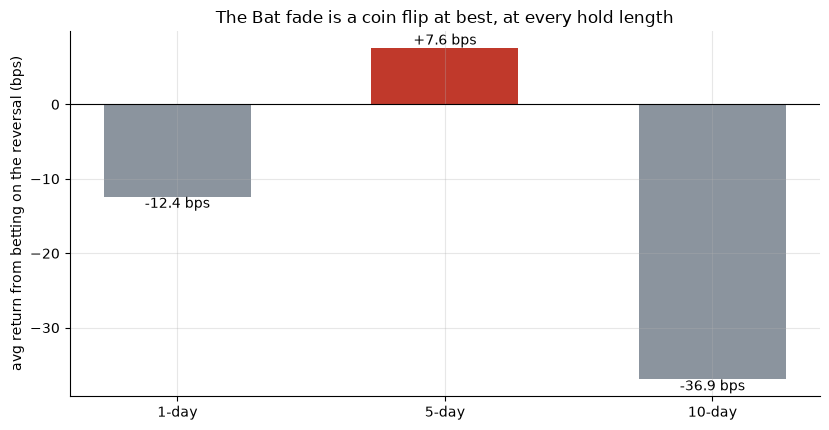

{1: np.float64(-12.4), 5: np.float64(7.6), 10: np.float64(-36.9)}


In [2]:
if HAVE_REAL:
    bat = pooled(placebo=False)
    hs = [1, 5, 10]
    ms = {h: bat[f'ret_gross_{h}'].mean() * 1e4 if len(bat) else np.nan for h in hs}
else:
    hs = [1, 5, 10]
    ms = {h: R['bat'][h]['mean'] for h in hs}
fig, ax = plt.subplots(figsize=(8.4, 4.4))
cols = [RED if h == 5 else GREY for h in hs]
ax.bar([f'{h}-day' for h in hs], [ms[h] for h in hs], color=cols, width=.55)
for i,h in enumerate(hs): ax.annotate(f'{ms[h]:+.1f} bps',(i,ms[h]),ha='center',
    va='top' if ms[h]<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('avg return from betting on the reversal (bps)')
ax.set_title('The Bat fade is a coin flip at best, at every hold length')
plt.tight_layout(); plt.show()
print({h: round(ms[h],1) for h in hs})

The 5-day headline: **+7.58 bps per event** — essentially nothing — with a hit rate of **40.4%**, *below* a coin flip. The 1-day and 10-day versions are outright negative.

**Is that just "no better than a coin flip", or actually *worse* than the market's own drift?** This is where the matched random-day control earns its keep:

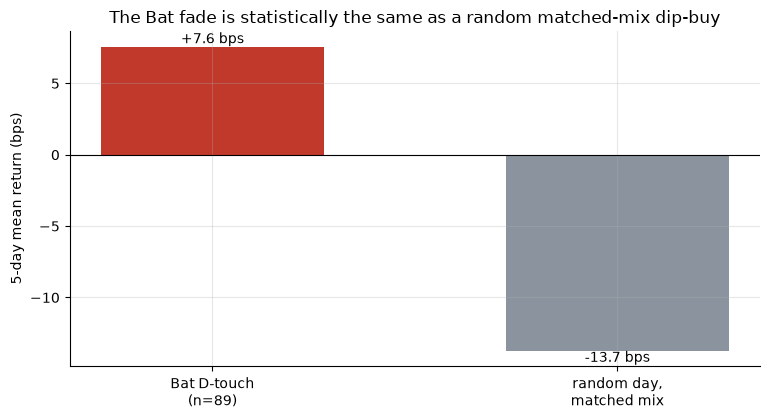

Bat +7.6 bps  vs  random-day control -13.7 bps


In [3]:
if HAVE_REAL:
    bat_l = pooled(placebo=False)
    base_l = base_rate_pool({t: st.detect_and_scan(BARS[t], pct=0.02, cost_bps=0.0)[2] for t in BASKET})
    bm = bat_l['ret_gross_5'].mean()*1e4 if len(bat_l) else np.nan
    rm = base_l['ret_gross_5'].mean()*1e4 if len(base_l) else np.nan
else:
    bm, rm = R['bat'][5]['mean'], R['base_mean_h'][5]
fig, ax = plt.subplots(figsize=(7.8, 4.3))
ax.bar(['Bat D-touch\n(n={})'.format(R['n_bat']), 'random day,\nmatched mix'],
       [bm, rm], color=[RED, GREY], width=.55)
for i,v in enumerate([bm, rm]): ax.annotate(f'{v:+.1f} bps',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('5-day mean return (bps)')
ax.set_title('The Bat fade is statistically the same as a random matched-mix dip-buy')
plt.tight_layout(); plt.show()
print(f'Bat {bm:+.1f} bps  vs  random-day control {rm:+.1f} bps')

Practically identical — and the difference (Welch *t* = +0.45) isn't remotely statistically real. **We also sliced the basket seven ways** (the pooled number plus each of the six tickers on its own) — the honest thing to do is admit we looked seven times and pay the Bonferroni penalty for it:

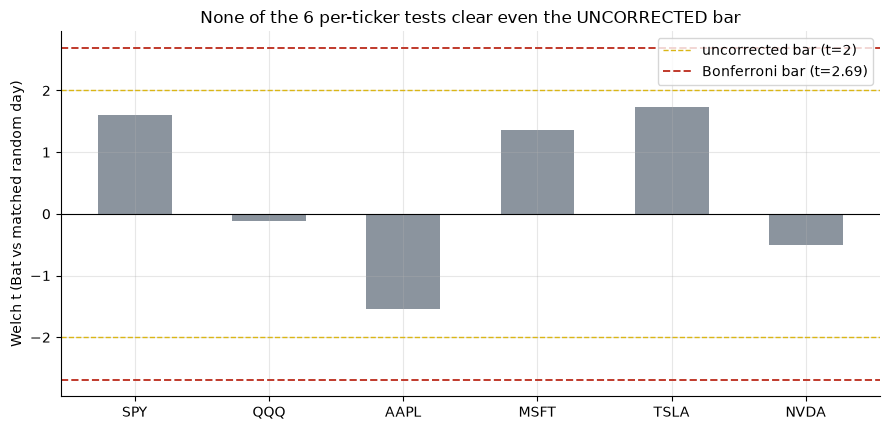

{'SPY': 1.61, 'QQQ': -0.11, 'AAPL': -1.54, 'MSFT': 1.36, 'TSLA': 1.73, 'NVDA': -0.5}


In [4]:
tickers = list(R['per_instrument'])
wts = [R['per_instrument'][t]['base_t'] for t in tickers]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
cols = [RED if abs(w) >= R['bonf_thr'] else GREY for w in wts]
ax.bar(tickers, wts, color=cols, width=.55)
ax.axhline(2.0, ls='--', c=AMBER, lw=1, label='uncorrected bar (t=2)')
ax.axhline(-2.0, ls='--', c=AMBER, lw=1)
ax.axhline(2.69, ls='--', c=RED, lw=1.4, label='Bonferroni bar (t=2.69)')
ax.axhline(-2.69, ls='--', c=RED, lw=1.4)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Welch t (Bat vs matched random day)')
ax.set_title('None of the 6 per-ticker tests clear even the UNCORRECTED bar')
ax.legend(); plt.tight_layout(); plt.show()
print(dict(zip(tickers, [round(w,2) for w in wts])))

Zero of the six per-ticker tests, plus the pooled headline, clear even the naive *t* = 2 bar — **0 of 7 tests survive**, whether or not you apply the Bonferroni correction (which raises the bar further, to **2.69**, once you account for having looked seven times).

**Finally, the second control: is 0.886 actually the special number, or would any nearby target have done just as well?**

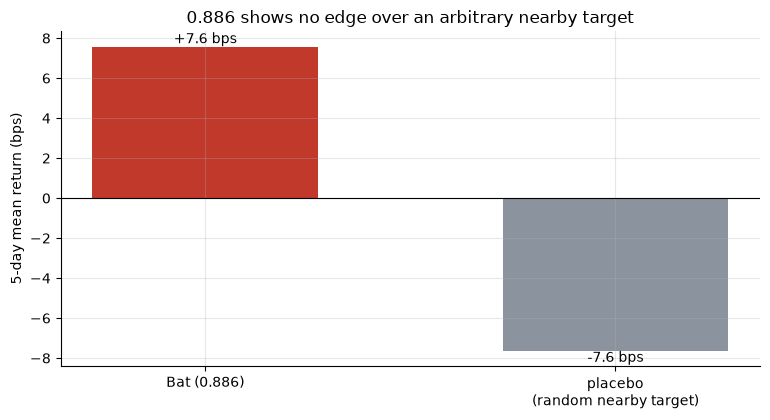

Bat +7.6 bps  vs  placebo -7.6 bps


In [5]:
if HAVE_REAL:
    bat_l = pooled(placebo=False); plac_l = pooled(placebo=True)
    bm = bat_l['ret_gross_5'].mean()*1e4 if len(bat_l) else np.nan
    pm = plac_l['ret_gross_5'].mean()*1e4 if len(plac_l) else np.nan
else:
    bm, pm = R['bat'][5]['mean'], R['plac_mean_h'][5]
fig, ax = plt.subplots(figsize=(7.8, 4.3))
ax.bar(['Bat (0.886)', 'placebo\n(random nearby target)'], [bm, pm],
       color=[RED, GREY], width=.55)
for i,v in enumerate([bm, pm]): ax.annotate(f'{v:+.1f} bps',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('5-day mean return (bps)')
ax.set_title('0.886 shows no edge over an arbitrary nearby target')
plt.tight_layout(); plt.show()
print(f'Bat {bm:+.1f} bps  vs  placebo {pm:+.1f} bps')

The real 0.886 ratio beats its own placebo control on only **2 of 6** tickers — no better than a coin flip. There is nothing detectably special about Carney's specific number here.

**And does it at least survive costs?** No — the best gross case (5-day, +7.6 bps) turns **negative** the instant you charge a single 5 bps one-way cost, and every longer hold we tried loses more, not less.

## 5 · The verdict

- **Signal — None.** The Bat fade returned **+7.58 bps/event** (HAC t = +0.17) with a hit rate below a coin flip, and none of 7 Bonferroni-corrected comparisons against a drift-matched random-day control survive.
- **Tradability — Mirage.** No hold length clears significance on the positive side, and the best case turns negative at a single 5 bps cost.
- **"Beats a placebo, i.e. is 0.886 the most reliable ratio?" — Busted.** The Bat's own defining number wins on only 2 of 6 tickers against an arbitrary nearby target.

## 6 · Going further 🚪

- **"Most reliable" is a comparative claim, and this study measures it directly.** Carney doesn't just claim the Bat works — he claims it works *better* than Gartley, Butterfly and Crab. See [698-abcd-harmonic](../../698-abcd-harmonic/) (the bare AB=CD skeleton), [699-butterfly-harmonic](../../699-butterfly-harmonic/) (D *overshoots* X instead of staying inside it) and [468-gartley-harmonic](../../468-gartley-harmonic/) (a shallower 0.786 D) for the rest of the comparison — none of them clears its own bar either.
- **Sibling study:** [77-golden-mean](../../77-golden-mean/) tests plain Fibonacci retracement *levels* (not a multi-pivot pattern) on the same six tapes and reaches the identical verdict shape: Fibonacci ratios show no specificity over a randomized control.

*Think you can find the real edge in a stricter version of the pattern (a tighter 0.886 tolerance, an added confluence check)? Show it beats this exact placebo — same pivots, same tape, only the ratio changes — and beats the drift-matched base rate after a Bonferroni correction, and we'll take a look.*